# 运营与数据质量

读取真实全年产物，追溯来源、清洗分母和经营规律。完整处理入口为 `python -m src.run_pipeline --stage all --seed 42`。

In [1]:
from pathlib import Path
import json
import pandas as pd
ROOT=Path.cwd()
assert (ROOT/'src').exists()
pd.set_option('display.max_columns',20)

In [2]:
manifest=json.loads((ROOT/'data/source_manifest.json').read_text(encoding='utf-8'))
print('完整来源:',manifest['complete'])
print('原始记录:',sum(x['rows'] for x in manifest['files'] if x['kind']=='trip'))
quality=pd.read_csv(ROOT/'reports/tables/data_quality_monthly.csv')
quality

完整来源: True
原始记录: 48722602


,source_month,raw_rows,outside_source_month,voided_in_scope,unknown_pickup,demand_rows,in_scope_rows,fare_rows,efficiency_rows,tip_rows,negative_amount,extreme_amount,missing_amount,bad_duration,bad_distance,bad_speed,dst_efficiency_excluded,flagged_rows,identical_field_extra_rows
0,2025-01,3475226,22,0,9521,3465683,3475204,3265934,3372327,2436934,144833,3,0,3428,91055,3028,0,249991,0
1,2025-02,3577543,31,0,8635,3568877,3577512,3332494,3463597,2329325,183140,6,0,6465,99943,5999,0,295230,0
2,2025-03,4145257,33,0,9235,4135989,4145224,3859564,3892191,2696899,209261,5,0,23854,103936,23328,119787,345091,0
3,2025-04,3970553,7,0,8991,3961555,3970546,3703964,3834977,2679730,187110,3,0,36362,91745,35863,0,325959,0
4,2025-05,4591845,24,0,9687,4582134,4591821,4179940,4377272,2834506,325994,3,0,65802,141491,65538,0,531207,0
5,2025-06,4322960,20,0,8595,4314345,4322940,3965797,4111752,2588456,276316,6,0,69963,135160,70098,0,484080,0
6,2025-07,3898963,7,0,8366,3890590,3898956,3569233,3711780,2337366,247574,7,0,57282,124048,57105,0,433021,1
7,2025-08,3574091,17,0,7607,3566467,3574074,3230093,3414519,2176960,261612,6,0,49115,105429,48902,0,421970,0
8,2025-09,4251015,7,0,8215,4242793,4251008,3914048,4061292,2669886,253353,3,0,58744,124697,58390,0,442281,0
9,2025-10,4428699,13,0,8542,4420144,4428686,4029772,4226553,2911805,321981,2,0,69654,125828,69256,0,515571,0


In [3]:
assert (quality.raw_rows==quality.outside_source_month+quality.voided_in_scope+quality.unknown_pickup+quality.demand_rows).all()
print('分月源记录、排除记录与需求记录对账通过')
pd.read_csv(ROOT/'reports/tables/kpi_summary.csv')

分月源记录、排除记录与需求记录对账通过


,trips,fare_n,fare_sum,total_charge_sum,efficiency_n,distance_km_sum,duration_min_sum,speed_kmh_sum,tip_n,tip_sum,tip_fare_sum,flagged_n,avg_fare,avg_total_charge,avg_distance_km,avg_duration_min,avg_speed_kmh,tip_rate,flag_rate
0,48619345,44970845,9.027046e+08,1.299042e+09,46406152,2.619121e+08,8.009758e+08,8.252363e+08,30972336,134144083.7,6.127669e+08,4793012,20.073108,28.886312,5.643908,17.260122,17.782907,0.218915,0.098582


In [4]:
pd.read_csv(ROOT/'reports/tables/zone_metrics.csv').nlargest(10,'trips')[['zone_id','zone','trips','avg_fare','avg_duration_min','flag_rate']]

,zone_id,zone,trips,avg_fare,avg_duration_min,flag_rate
233,237,Upper East Side South,2125557,13.463852,12.374752,0.062287
157,161,Midtown Center,2089747,16.909264,15.591976,0.072050
128,132,JFK Airport,2062443,63.964844,42.880314,0.133213
232,236,Upper East Side North,1874805,13.992359,12.604780,0.070983
182,186,Penn Station/Madison Sq West,1543158,17.223656,16.640327,0.069075
226,230,Times Sq/Theatre District,1516398,19.649214,16.874660,0.086640
158,162,Midtown East,1508176,16.251478,14.900258,0.066894
138,142,Lincoln Square East,1387603,14.831112,13.155903,0.075715
166,170,Murray Hill,1294383,16.184105,14.629207,0.087002
230,234,Union Sq,1293635,15.326682,14.160485,0.084324


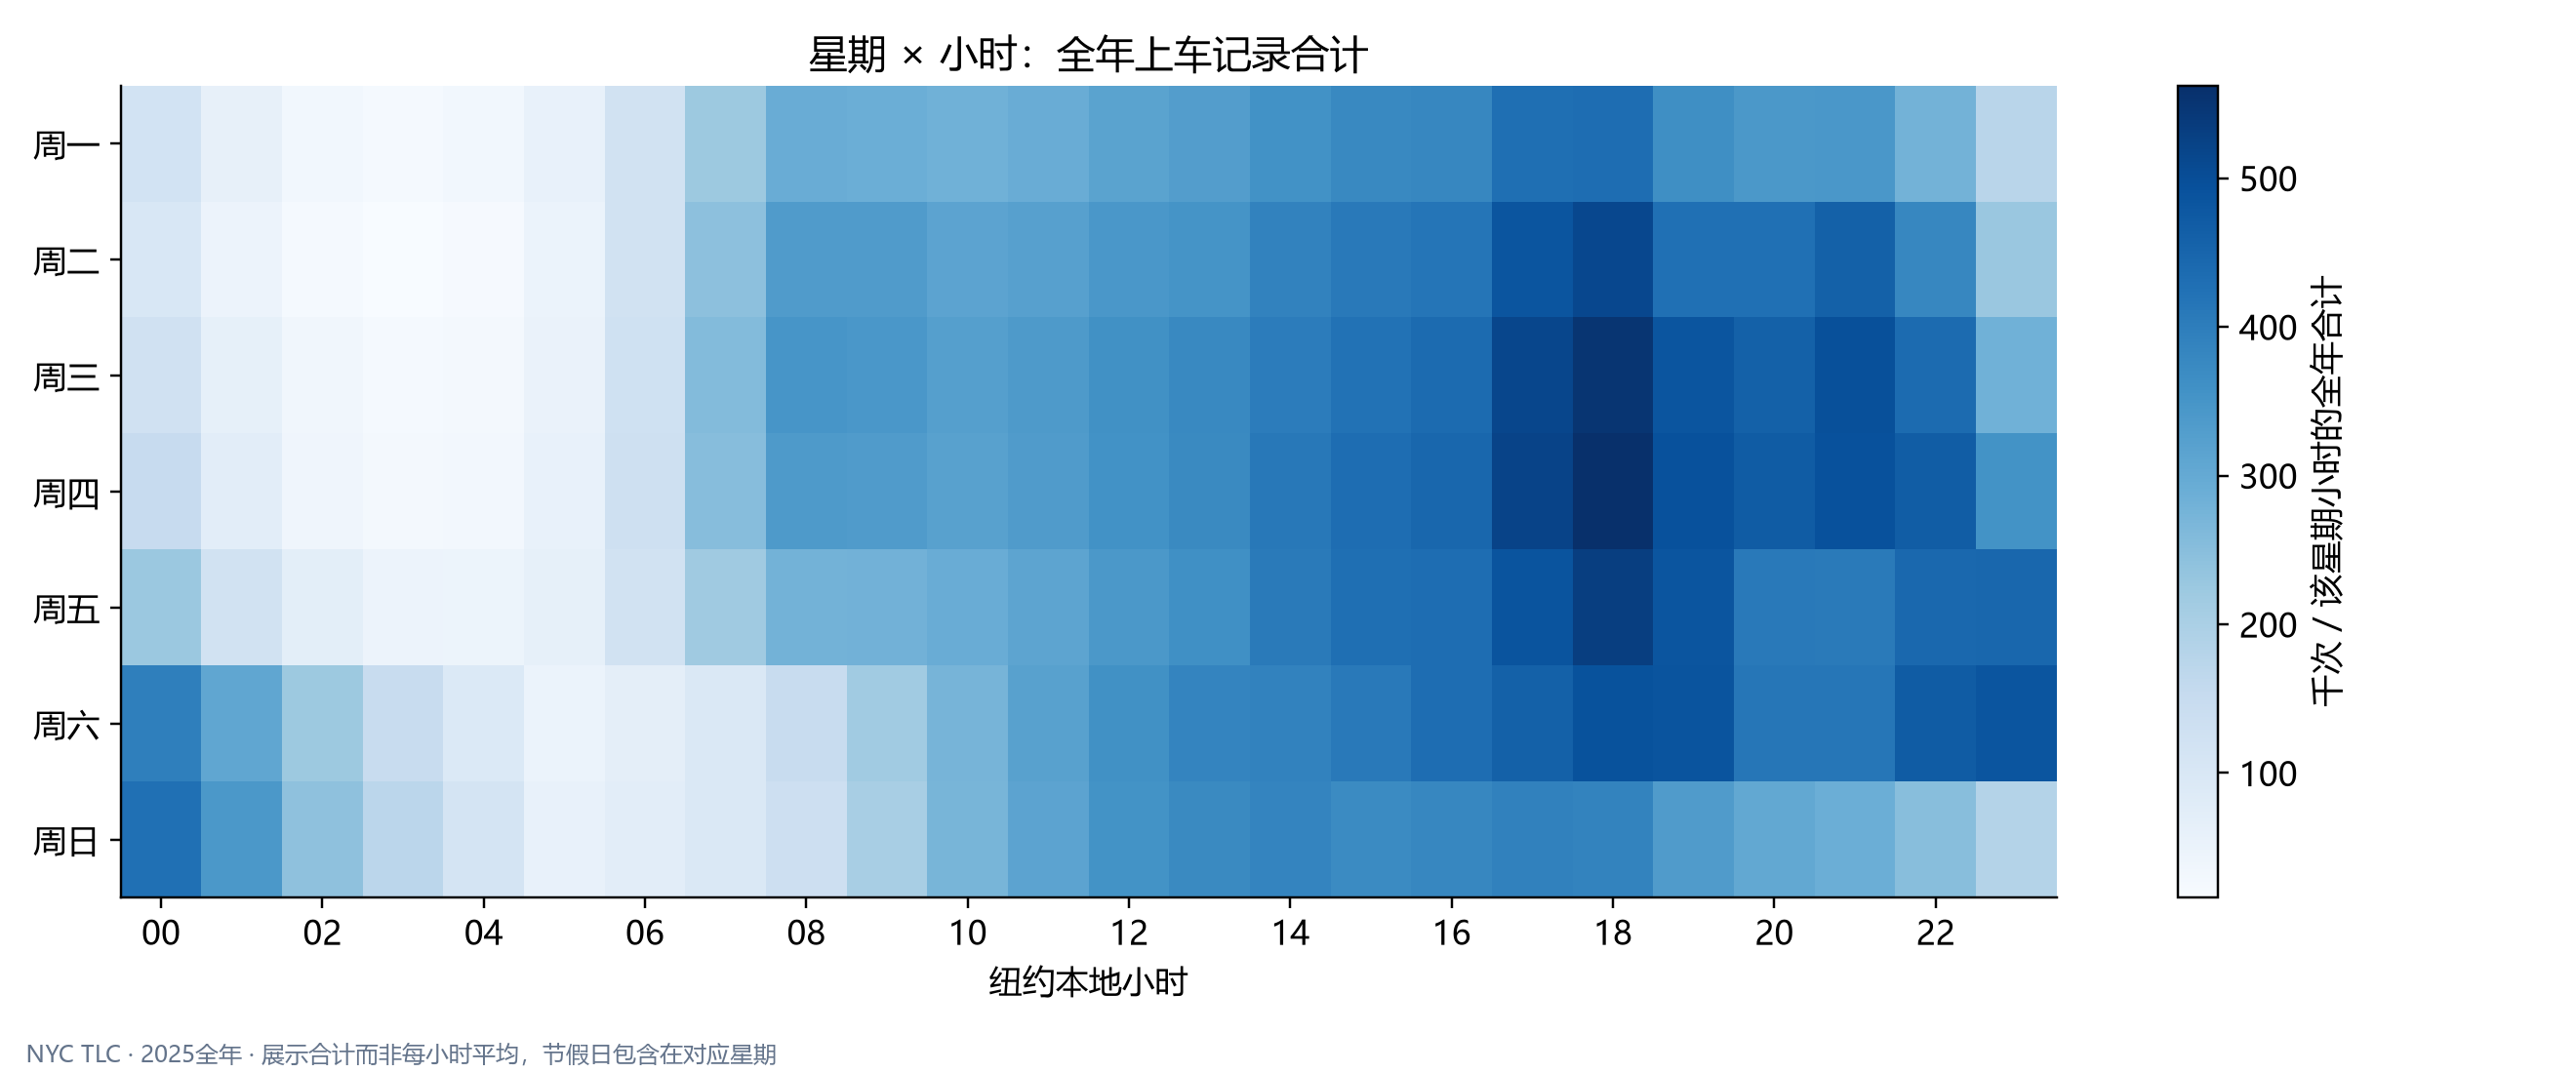

In [5]:
from IPython.display import Image,display
display(Image(filename=str(ROOT/'reports/figures/02_weekday_hour.png'),width=900))

解释：这里的规模是已记录上车记录，不是全部潜在需求。小费率只有银行卡口径，未知区域和效率分母另计。天气比较为描述性，不能归因为天气造成了需求变化。